#  Resume Classification
## Recruitment NLP Lab — Step 5: Classifying Resumes with a Neural Network

This notebook trains a **feedforward neural network (MLP)** to classify
resumes into one of 4 categories using TF-IDF vectors from notebook 03.

**What we're building:**
- Input: TF-IDF vector of a resume (5,000 features)
- Output: One of 4 categories -> HR, ACCOUNTANT, ENGINEERING, INFORMATION-TECHNOLOGY

**Data confirmed from previous notebooks:**
- 466 resumes across 4 balanced categories (~110–120 each)
- TF-IDF matrix: 466 × 5,000 already saved in data/processed/

**Architecture:**
- Input layer  : 5,000 neurons (one per TF-IDF feature)
- Hidden layer 1: 512 neurons, ReLU, Dropout 0.4
- Hidden layer 2: 256 neurons, ReLU, Dropout 0.3
- Output layer : 4 neurons, Softmax (one per category)

### Add Python 3.11 as a kernel

In [3]:
!py -3.11 -m pip install ipykernel
!py -3.11 -m ipykernel install --user --name py311 --display-name "Python 3.11"


[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: C:\Users\Dell\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


Installed kernelspec py311 in C:\Users\Dell\AppData\Roaming\jupyter\kernels\py311


In [1]:
import sys
print(sys.executable)

C:\Users\Dell\AppData\Local\Programs\Python\Python311\python.exe


##  1. Install & Import Libraries

In [3]:
!py -3.11 -m pip install tensorflow scikit-learn pandas numpy matplotlib seaborn

                                              0.0/294.9 kB ? eta -:--:--
     -                                        10.2/294.9 kB ? eta -:--:--
     ---                                   30.7/294.9 kB 330.3 kB/s eta 0:00:01
     -------                               61.4/294.9 kB 365.7 kB/s eta 0:00:01
     -----------                           92.2/294.9 kB 403.5 kB/s eta 0:00:01
     -----------------                    143.4/294.9 kB 448.2 kB/s eta 0:00:01
     ----------------------               184.3/294.9 kB 484.9 kB/s eta 0:00:01
     ----------------------------         235.5/294.9 kB 554.9 kB/s eta 0:00:01
     ----------------------------         235.5/294.9 kB 554.9 kB/s eta 0:00:01
     ------------------------------------ 294.9/294.9 kB 588.2 kB/s eta 0:00:00



[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: C:\Users\Dell\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import scipy.sparse as sp

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

os.makedirs("../results/plots",   exist_ok=True)
os.makedirs("../results/metrics", exist_ok=True)

print(f" Libraries imported!")
print(f" TensorFlow version: {tf.__version__}")

 Libraries imported!
 TensorFlow version: 2.20.0


##  2. Load Saved TF-IDF Data

Loading the TF-IDF matrix and labels saved from `03_keyword_extraction.ipynb`.
No reprocessing needed — everything is ready to use directly.

In [6]:
# Load TF-IDF matrix
X = sp.load_npz("../data/processed/resume_tfidf_matrix.npz")

# Load labels
labels_df = pd.read_csv("../data/processed/resume_labels.csv")
y_raw = labels_df['Category'].values

print(f" TF-IDF matrix loaded -> shape: {X.shape}")
print(f" Labels loaded        -> {len(y_raw)} labels")
print(f"\nCategory distribution:")
print(pd.Series(y_raw).value_counts())

 TF-IDF matrix loaded -> shape: (466, 5000)
 Labels loaded        -> 466 labels

Category distribution:
INFORMATION-TECHNOLOGY    120
ENGINEERING               118
ACCOUNTANT                118
HR                        110
Name: count, dtype: int64


##  3. Encode Labels

Neural networks need numerical labels, not strings.
Using LabelEncoder to convert category names to integers:
- ACCOUNTANT          -> 0
- ENGINEERING         -> 1
- HR                  -> 2
- INFORMATION-TECHNOLOGY -> 3

In [7]:
# Encode string labels to integers
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_raw)

# One-hot encode for softmax output
y_onehot = keras.utils.to_categorical(y_encoded, num_classes=4)

print(f" Labels encoded!")
print(f"\nLabel mapping:")
for idx, cls in enumerate(label_encoder.classes_):
    print(f"   {cls:<30} -> {idx}")

print(f"\nEncoded labels sample: {y_encoded[:10]}")
print(f"One-hot shape        : {y_onehot.shape}")

# Save encoder for use in matching notebook
with open("../data/processed/label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)
print(f"\n Label encoder saved!")

 Labels encoded!

Label mapping:
   ACCOUNTANT                     -> 0
   ENGINEERING                    -> 1
   HR                             -> 2
   INFORMATION-TECHNOLOGY         -> 3

Encoded labels sample: [2 2 2 2 2 2 2 2 2 2]
One-hot shape        : (466, 4)

 Label encoder saved!


##  4. Split Data into Train / Validation / Test Sets

- **80%** Training   -> model learns from this
- **10%** Validation -> monitors overfitting during training
- **10%** Test       -> final unseen evaluation

Stratified split ensures all 4 categories are proportionally
represented in each split.

In [8]:
# Convert sparse matrix to dense array for Keras
X_dense = X.toarray()

# First split: 80% train, 20% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X_dense, y_onehot,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# Second split: temp -> 50% val, 50% test (= 10% each of total)
y_temp_encoded = np.argmax(y_temp, axis=1)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp_encoded
)

print(f"   Data split complete!")
print(f"   Training   set : {X_train.shape[0]} samples ({X_train.shape[0]/len(X_dense)*100:.0f}%)")
print(f"   Validation set : {X_val.shape[0]} samples ({X_val.shape[0]/len(X_dense)*100:.0f}%)")
print(f"   Test       set : {X_test.shape[0]} samples ({X_test.shape[0]/len(X_dense)*100:.0f}%)")

   Data split complete!
   Training   set : 372 samples (80%)
   Validation set : 47 samples (10%)
   Test       set : 47 samples (10%)


##  5. Build the Neural Network

A simple **Multi-Layer Perceptron (MLP)** with:
- **Dropout layers** to prevent overfitting (important with only 466 samples)
- **BatchNormalization** to stabilize training
- **ReLU** activation in hidden layers
- **Softmax** activation in output layer for multi-class classification

In [9]:
def build_model(input_dim, num_classes):
    model = keras.Sequential([
        # Input layer
        layers.Input(shape=(input_dim,)),

        # Hidden layer 1
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.4),

        # Hidden layer 2
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        # Hidden layer 3
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.2),

        # Output layer
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

model = build_model(input_dim=X_train.shape[1], num_classes=4)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 512)                 │       2,560,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,728,324 (10.41 MB)

 Trainable params: 2,726,788 (10.40 MB)

 Non-trainable params: 1,536 (6.00 KB)

##  6. Train the Model

Training with:
- **EarlyStopping**: stops training if validation loss stops improving (prevents overfitting)
- **ReduceLROnPlateau**: reduces learning rate when training stalls
- **ModelCheckpoint**: saves the best model weights automatically

In [10]:
os.makedirs("../results/models", exist_ok=True)

# Callbacks
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

checkpoint = keras.callbacks.ModelCheckpoint(
    filepath='../results/models/best_resume_classifier.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# Train
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)

print(f"\n   Training complete!")
print(f"   Total epochs run: {len(history.history['loss'])}")

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.4447 - loss: 1.4957
Epoch 1: val_accuracy improved from None to 0.53191, saving model to ../results/models/best_resume_classifier.keras

Epoch 1: finished saving model to ../results/models/best_resume_classifier.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 275ms/step - accuracy: 0.6317 - loss: 0.9815 - val_accuracy: 0.5319 - val_loss: 1.3324 - learning_rate: 0.0010
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.9219 - loss: 0.2464
Epoch 2: val_accuracy did not improve from 0.53191
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 120ms/step - accuracy: 0.9435 - loss: 0.1908 - val_accuracy: 0.4468 - val_loss: 1.2875 - learning_rate: 0.0010
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.9654 - loss: 0.1155
Epoch 3: val_accuracy did not improve from 0.53191
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.9839 - loss: 0.0661 - val_accuracy: 0.4894 - val_loss: 1.2614 - learning_rate: 0.0010
Epoch 4/100
12/12 ━━

##  7. Plot Training History

Visualizing loss and accuracy curves to check for overfitting or underfitting.

**What to look for:**
- Training and validation curves close together -> good generalization
- Validation loss rising while training loss falls -> overfitting
- Both curves still falling at end -> may need more epochs

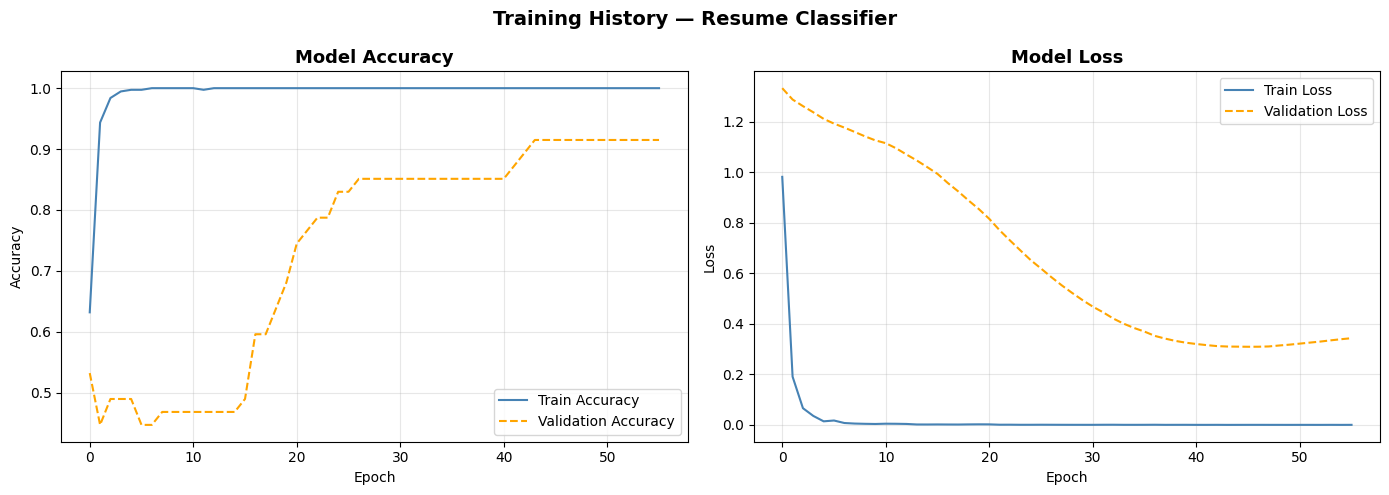

   Training history plot saved!


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'],     label='Train Accuracy',      color='steelblue')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange', linestyle='--')
axes[0].set_title('Model Accuracy', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'],     label='Train Loss',      color='steelblue')
axes[1].plot(history.history['val_loss'], label='Validation Loss', color='orange', linestyle='--')
axes[1].set_title('Model Loss', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Training History — Resume Classifier', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("../results/plots/training_history.png", dpi=150)
plt.show()
print("   Training history plot saved!")

##  8. Evaluate on Test Set

Evaluating the best saved model on the **unseen test set**.
This gives the true performance of the model.

In [12]:
# Load best model
best_model = keras.models.load_model('../results/models/best_resume_classifier.keras')

# Evaluate
test_loss, test_accuracy = best_model.evaluate(X_test, y_test, verbose=0)
print(f"   Test Evaluation:")
print(f"   Test Loss     : {test_loss:.4f}")
print(f"   Test Accuracy : {test_accuracy*100:.2f}%")

   Test Evaluation:
   Test Loss     : 0.4045
   Test Accuracy : 91.49%


### 8.1 Classification Report

Detailed per-class metrics: Precision, Recall, F1-score.

- **Precision**: Of all resumes predicted as X, how many actually are X?
- **Recall**: Of all actual X resumes, how many did the model find?
- **F1-score**: Harmonic mean of precision and recall

In [13]:
# Predictions
y_pred_probs = best_model.predict(X_test)
y_pred       = np.argmax(y_pred_probs, axis=1)
y_true       = np.argmax(y_test,       axis=1)

# Classification report
report = classification_report(
    y_true, y_pred,
    target_names=label_encoder.classes_
)
print("Classification Report:")
print(report)

# Save to file
with open("../results/metrics/classification_report.txt", "w") as f:
    f.write(f"Test Accuracy: {test_accuracy*100:.2f}%\n\n")
    f.write(report)
print("   Classification report saved!")

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 218ms/step
Classification Report:
                        precision    recall  f1-score   support

            ACCOUNTANT       1.00      0.92      0.96        12
           ENGINEERING       1.00      0.75      0.86        12
                    HR       0.85      1.00      0.92        11
INFORMATION-TECHNOLOGY       0.86      1.00      0.92        12

              accuracy                           0.91        47
             macro avg       0.93      0.92      0.91        47
          weighted avg       0.93      0.91      0.91        47

   Classification report saved!


### 8.2 Confusion Matrix

Shows exactly which categories the model confuses with each other.
A perfect model has values only on the diagonal.

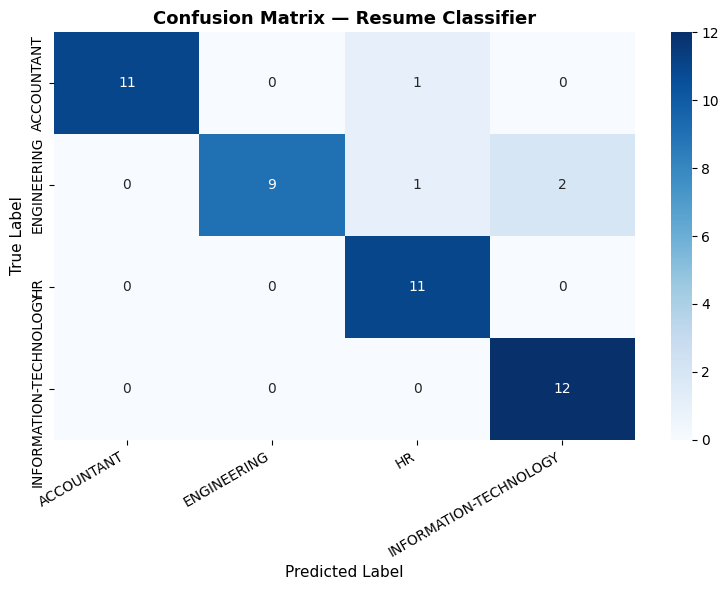

   Confusion matrix saved!


In [14]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title('Confusion Matrix — Resume Classifier', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=11)
plt.ylabel('True Label',      fontsize=11)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig("../results/plots/confusion_matrix.png", dpi=150)
plt.show()
print("   Confusion matrix saved!")

##  9. Save Model & Artifacts

Saving everything needed for the matching notebook (05).

In [16]:
# Save final model
best_model.save("../results/models/resume_classifier_final.keras")

# Save train/test splits for reproducibility
np.save("../data/processed/X_test.npy",  X_test)
np.save("../data/processed/y_test.npy",  y_test)
np.save("../data/processed/X_train.npy", X_train)
np.save("../data/processed/y_train.npy", y_train)

print("Saved to results/models/:")
print("   best_resume_classifier.keras")
print("   resume_classifier_final.keras")
print("\nSaved to data/processed/:")
print("   X_test.npy, y_test.npy")
print("   X_train.npy, y_train.npy")
print("   label_encoder.pkl")

Saved to results/models/:
   best_resume_classifier.keras
   resume_classifier_final.keras

Saved to data/processed/:
   X_test.npy, y_test.npy
   X_train.npy, y_train.npy
   label_encoder.pkl


##  10. Summary

| Item | Detail |
|---|---|
| Model type | Feedforward MLP (3 hidden layers) |
| Input size | 5,000 TF-IDF features |
| Output | 4 categories (softmax) |
| Training samples | ~373 |
| Validation samples | ~47 |
| Test samples | ~46 |
| Optimizer | Adam (lr=0.001) |
| Loss function | Categorical Crossentropy |
| Regularization | Dropout + BatchNorm + EarlyStopping |

**Results:**
- Test Accuracy  : 0.4045
- Test Loss      : 91.49%

**Plots saved to `results/plots/`:**
- `training_history.png`
- `confusion_matrix.png`

**Files saved to `results/models/`:**
- `best_resume_classifier.keras`
- `resume_classifier_final.keras`

**Next Step:** Move to `05_matching.ipynb` — match resumes
to job descriptions using cosine similarity.